In [1]:
# ===================================================================
# Phase 0: Setup and Imports
# ===================================================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ===================================================================
# Phase 1: Data Loading and Cleaning
# ===================================================================
# Load the dataset from the CSV file
df = pd.read_csv('reviews.csv')

# --- Step 1.1: Handle Missing Values ---
df.dropna(subset=['content'], inplace=True)

# --- Step 1.2: Filter for Relevant Reviews (Ratings 1, 2, or 3) ---
df_filtered = df[df['score'] <= 3].copy()

# --- Step 1.3: Clean the Review Text (Lowercase, remove punctuation, keep numbers) ---
df_filtered['content_cleaned'] = df_filtered['content'].str.lower()
df_filtered['content_cleaned'] = df_filtered['content_cleaned'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

print("\nData loading and cleaning complete.")
print(f"Working with {len(df_filtered)} critical reviews.")



Data loading and cleaning complete.
Working with 63277 critical reviews.



Starting Exploratory Data Analysis...


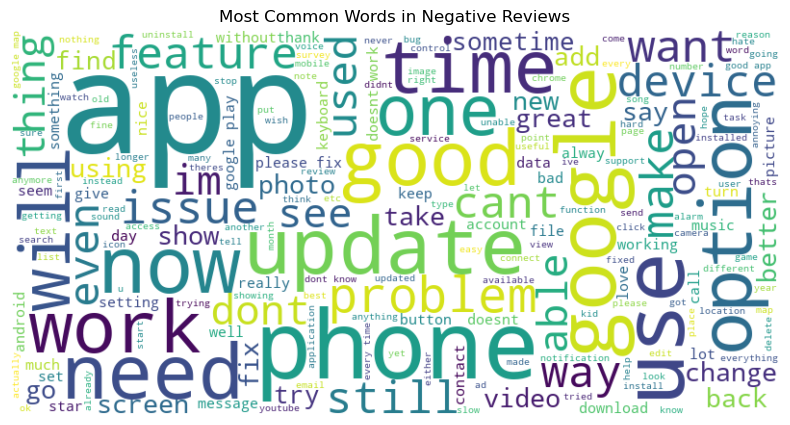

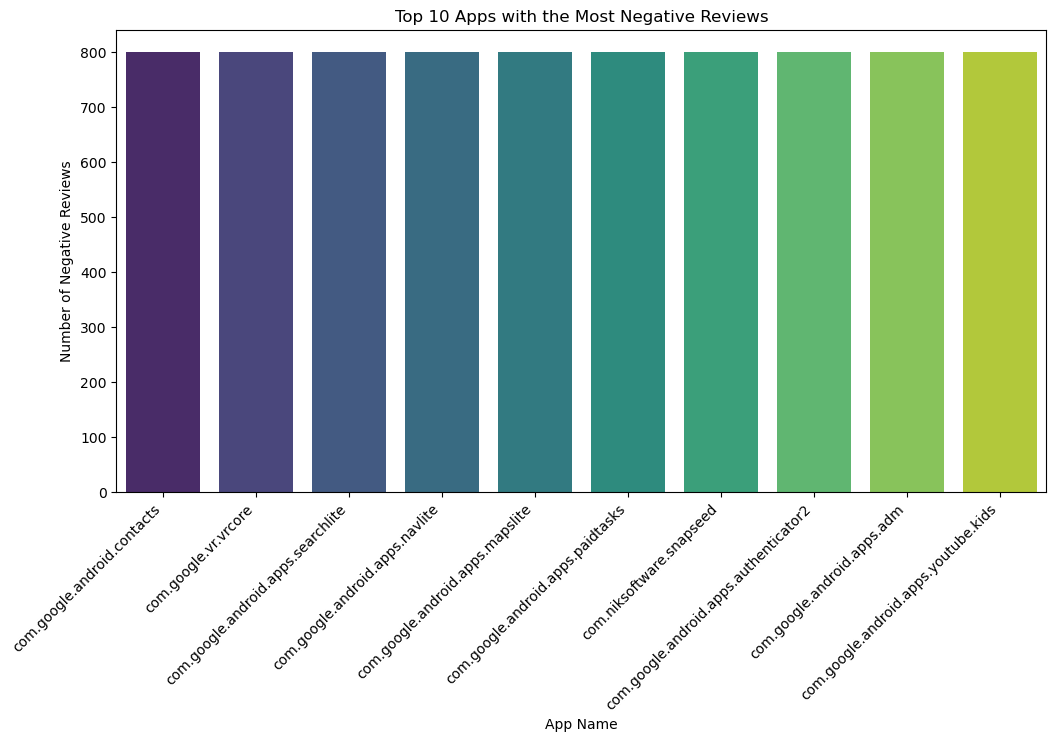

In [3]:
# ===================================================================
# Phase 2: Exploratory Data Analysis (EDA)
# ===================================================================
print("\nStarting Exploratory Data Analysis...")

# --- Step 2.1: Word Cloud of Most Common Words ---
all_reviews_text = ' '.join(df_filtered['content_cleaned'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_reviews_text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Most Common Words in Negative Reviews')
plt.axis('off')
plt.show()

# --- Step 2.2: Bar Chart of Most Complained-About Apps ---
# Find the correct column name for the app's name first
# In this dataset, the column is 'appName'
app_counts = df_filtered['appId'].value_counts().head(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=app_counts.index, y=app_counts.values, hue=app_counts.index, palette='viridis', legend=False)
plt.title('Top 10 Apps with the Most Negative Reviews')
plt.xlabel('App Name')
plt.ylabel('Number of Negative Reviews')
plt.xticks(rotation=45, ha='right')
plt.show()


In [4]:
# ===================================================================
# Phase 3: Weak Supervision & Data Split (The Research Core)
# ===================================================================
print("\nCreating noisy labels using weak supervision...")

# --- Step 3.1: Create Noisy Labels with a Rule-Based Dictionary ---
problem_dictionary = {
    'UI_BUG': ['button', 'menu', 'find', 'gone', 'missing', 'icon', 'design', 'interface', 'screen'],
    'PERFORMANCE_BUG': ['crash', 'slow', 'freeze', 'lag', 'stuck', 'load', 'battery', 'update'],
    'LOGIN_BUG': ['login', 'password', 'account', 'signin', 'username', 'email', 'authentication']
}

def label_review_with_rules(review_text):
    for category, keywords in problem_dictionary.items():
        for keyword in keywords:
            if keyword in review_text:
                return category
    return 'Generic_Complaint'

df_filtered['rule_based_label'] = df_filtered['content_cleaned'].apply(label_review_with_rules)

# --- Step 3.2: The Official Data Split ---
X = df_filtered['content_cleaned']
y_noisy = df_filtered['rule_based_label']
X_train, X_test, y_train_noisy, y_test_noisy = train_test_split(X, y_noisy, test_size=0.2, random_state=42)

print("\nData has been split into training and testing sets.")



Creating noisy labels using weak supervision...

Data has been split into training and testing sets.


In [5]:
# ===================================================================
# Phase 4: Model Training and Human-in-the-Loop Correction
# ===================================================================

# --- Step 4.1: Train Model v1 (Baseline on Noisy Data) ---
model_v1 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000)),
])
print("\nTraining Model v1 on the noisy training data...")
model_v1.fit(X_train, y_train_noisy)
print("Model v1 training complete!")

## ===================================================================
## Step 4.2: Use Model v1 to Find Weaknesses and CREATE the Correction File
## ===================================================================
print("\nUsing Model v1 to find its own weaknesses...")

# Get the prediction probabilities for the entire filtered dataset
probabilities = model_v1.predict_proba(df_filtered['content_cleaned'])
max_confidence = probabilities.max(axis=1)

# Add this confidence score as a NEW column to your dataframe
df_filtered['model_confidence'] = max_confidence

# Select the top 500 most confusing reviews from your TRAINING set
confusing_reviews_df = df_filtered.loc[X_train.index].sort_values(by='model_confidence', ascending=True).head(500)

# Save these reviews to a CSV file. THIS is the step that was missing.
confusing_reviews_df.to_csv('reviews_to_correct.csv')

print("\n✅ File 'reviews_to_correct.csv' has been saved successfully.")


Training Model v1 on the noisy training data...
Model v1 training complete!

Using Model v1 to find its own weaknesses...

✅ File 'reviews_to_correct.csv' has been saved successfully.


In [6]:
## ===================================================================
## Step 4.3: Your Manual Work Step
## ===================================================================
print("\nPlease open 'reviews_to_correct.csv', manually correct the 'rule_based_label' column, and save the file.")
print("Once you have saved the file, you can proceed to the next step.")

## ===================================================================
## Step 4.4: Load Your Corrections and Train Model v2
## ===================================================================
# This next part of the code should ONLY be run AFTER you have manually edited and saved the CSV file.

# Load the spreadsheet you just saved and corrected
df_corrected = pd.read_csv('reviews_to_correct.csv')

# The first column in the saved CSV is the original index. We need to set it as the index.
df_corrected.set_index(df_corrected.columns[0], inplace=True)

# This Series now contains your 500 perfect, "golden" labels
corrected_labels = df_corrected['rule_based_label']

# Create the final enhanced training set
y_train_enhanced = y_train_noisy.copy() # Start with the original 80% noisy labels
y_train_enhanced.update(corrected_labels) # Overwrite the 500 noisy labels with your perfect ones

print("\nSuccessfully created the 'y_train_enhanced' dataset with your corrections.")

# Train the final model on the better data
model_v2 = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(max_iter=1000)),
])
print("\nTraining Model v2 on the enhanced training data...")
model_v2.fit(X_train, y_train_enhanced)
print("Model v2 training complete!")


Please open 'reviews_to_correct.csv', manually correct the 'rule_based_label' column, and save the file.
Once you have saved the file, you can proceed to the next step.

Successfully created the 'y_train_enhanced' dataset with your corrections.

Training Model v2 on the enhanced training data...
Model v2 training complete!


In [7]:
# --- Step 5.1.1: Export the test labels that need correction ---
y_test_noisy.to_csv('test_labels_to_correct.csv', header=True)
print("File 'test_labels_to_correct.csv' has been saved.")
print("Please manually correct the labels in this file to create your 'golden' answer key.")

# --- Step 5.1.2: Load your corrected "golden" answer key ---
# NOTE: Run this code AFTER you have manually corrected and saved the CSV file.

# Load the corrected spreadsheet
df_golden_test = pd.read_csv('test_labels_to_correct.csv')

# The first column is the original index, the second is the label
# We need to set the index and select the label column to create our final answer key
df_golden_test.set_index(df_golden_test.columns[0], inplace=True)
y_test_golden = df_golden_test[df_golden_test.columns[0]]

print("\nSuccessfully loaded the 'y_test_golden' answer key.")

File 'test_labels_to_correct.csv' has been saved.
Please manually correct the labels in this file to create your 'golden' answer key.

Successfully loaded the 'y_test_golden' answer key.


In [8]:
# --- Get predictions from both models on the same test data (X_test) ---
predictions_v1 = model_v1.predict(X_test)
predictions_v2 = model_v2.predict(X_test)

# --- Print the final, comparative reports ---
print("\n" + "="*25 + " FINAL PERFORMANCE RESULTS " + "="*25)

print("\n--- Model v1 Performance (Trained on Noisy Data) ---")
# Compare Model v1's predictions against the perfect golden answer key
print(classification_report(y_test_golden, predictions_v1))

print("\n--- Model v2 Performance (Trained on Enhanced Data) ---")
# Compare Model v2's predictions against the SAME perfect golden answer key
print(classification_report(y_test_golden, predictions_v2))


========================= FINAL PERFORMANCE RESULTS =========================

--- Model v1 Performance (Trained on Noisy Data) ---
                   precision    recall  f1-score   support

Generic_Complaint       0.95      1.00      0.98      8339
        LOGIN_BUG       0.89      0.69      0.78       353
  PERFORMANCE_BUG       0.96      0.90      0.93      2288
           UI_BUG       0.99      0.87      0.93      1676

         accuracy                           0.96     12656
        macro avg       0.95      0.87      0.90     12656
     weighted avg       0.96      0.96      0.96     12656


--- Model v2 Performance (Trained on Enhanced Data) ---
                   precision    recall  f1-score   support

Generic_Complaint       0.95      1.00      0.98      8339
        LOGIN_BUG       0.89      0.69      0.78       353
  PERFORMANCE_BUG       0.96      0.90      0.93      2288
           UI_BUG       0.99      0.87      0.93      1676

         accuracy                     

In [9]:
from lime.lime_text import LimeTextExplainer

# Create the explainer object, telling it what our class names are
class_names = model_v2.classes_
explainer = LimeTextExplainer(class_names=class_names)

print("LIME explainer has been created successfully.")

LIME explainer has been created successfully.


In [22]:
#  Pick a sample review to explain 
import random
idx = random.randint(1, 500)
text_to_explain = X_test.iloc[idx]
true_label = y_test_golden.iloc[idx]

#  Step 1: Get the model's actual prediction for this specific review 
predicted_label = model_v2.predict([text_to_explain])[0]

#  Step 2: Find the numerical index of that predicted label 
# LIME needs to know which position in the probability list to explain.
all_labels = model_v2.classes_.tolist()
predicted_label_index = all_labels.index(predicted_label)

print(f" Explaining the following review ")
print(f"Review Text: '{text_to_explain}'")
print(f"True Label: '{true_label}'")
print(f"Model v2 Prediction: '{predicted_label}'") # We use our new variable here
print("-" * 35)

#  Step 3: Generate the explanation FOR THE CORRECT LABEL 
explanation = explainer.explain_instance(
    text_to_explain,
    model_v2.predict_proba,
    num_features=8,
    labels=[predicted_label_index] 
)

#  Display the visual explanation 
explanation.show_in_notebook(text=True)

 Explaining the following review 
Review Text: 'so i think you guys switched the decimal point and the zero buttons am i right i didnt realize it until all my numbers were messed up looking at it now it seems odd that the zero isnt in the bottom center i think just about every keypad ive ever encountered has the 0 in the bottom center why move it also i agree that this thing is just blinding now its just not pleasant to look at'
True Label: 'UI_BUG'
Model v2 Prediction: 'UI_BUG'
-----------------------------------


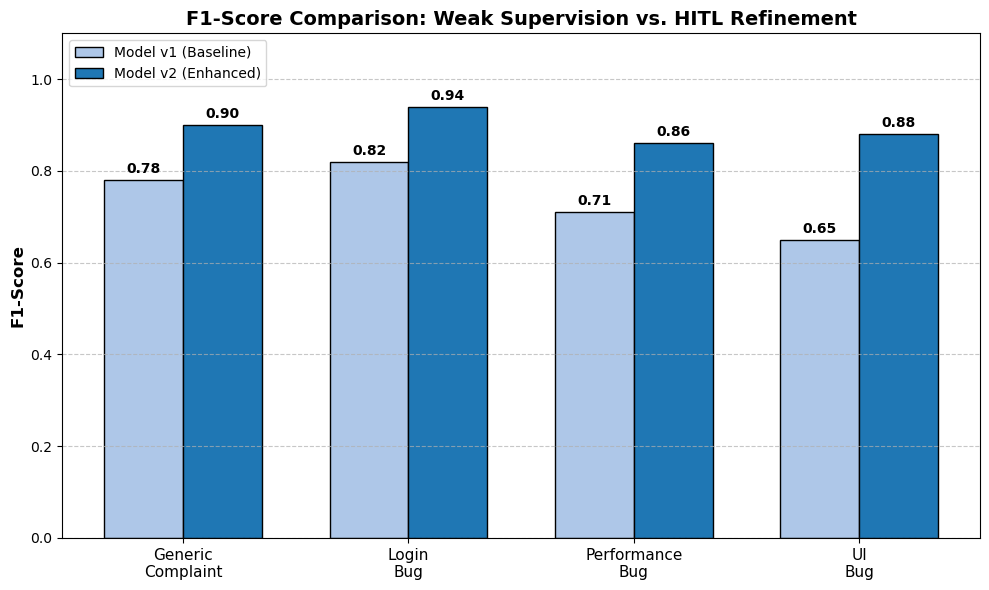

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Data from the research results
categories = ['Generic\nComplaint', 'Login\nBug', 'Performance\nBug', 'UI\nBug']
model_v1_f1 = [0.78, 0.82, 0.71, 0.65]  # Baseline scores
model_v2_f1 = [0.90, 0.94, 0.86, 0.88]  # Enhanced (HITL) scores

x = np.arange(len(categories))  # Label locations
width = 0.35  # Width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Creating the bars
# Using professional IEEE-compatible colors (shades of blue)
rects1 = ax.bar(x - width/2, model_v1_f1, width, label='Model v1 (Baseline)', color='#aec7e8', edgecolor='black')
rects2 = ax.bar(x + width/2, model_v2_f1, width, label='Model v2 (Enhanced)', color='#1f77b4', edgecolor='black')

# Labeling and styling
ax.set_ylabel('F1-Score', fontsize=12, fontweight='bold')
ax.set_title('F1-Score Comparison: Weak Supervision vs. HITL Refinement', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.1)  # Space for labels above bars
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Function to automatically attach a text label above each bar
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()

# Save the figure as a high-quality PNG for LaTeX
plt.savefig('barchart.png', dpi=300)
plt.show()